In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from config import DataConfig, ModelConfig, TrainConfig
from dataset_module import dataset_module
from student_module import student_module

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

print('PyTorch version:', torch.__version__)
print('Number of GPUs:', torch.cuda.device_count())
print('Current GPU:', torch.cuda.get_device_name(0))

PyTorch version: 2.8.0+cu128
Number of GPUs: 1
Current GPU: NVIDIA A30


In [2]:
# Load dataset
df_fcst = pd.read_csv('Sikorsky_fcst.csv')
df_fcst = df_fcst.rename(columns={'WSPD':'u'})
df_fcst['TmStamp'] = pd.to_datetime(df_fcst['TmStamp'], format='mixed')

# Parameters
context, horizon = 1024, 12

# ----- Dataset module -----
cols, df, df_train, df_val = dataset_module()
split = pd.to_datetime('2024-06-30 23:59:00')
df_test = df[df['TmStamp'] > split].reset_index(drop=True)
data_cfg = DataConfig(df_train=df_train, df_val=df_val, cols=cols)
model_cfg = ModelConfig(context=context, horizon=horizon, input_dim=len(cols)+1)

y_true, y_pred_p50 = [], []
y_pred_p95L, y_pred_p95U = [], []

for q in ['p50','p95L','p95U']:
    # ----- Teacher (Chronos) module -----
    train_preds = np.load('train_preds_' + q + '.npy')
    val_preds = np.load('val_preds_' + q + '.npy')
    train_cfg = TrainConfig(train_preds, val_preds)

    # ----- Student (TCN encoder + decoder) module -----
    student, _ = student_module(data_cfg, model_cfg, train_cfg)
    student_ckpt = torch.load('best_student_' + q + '.pt')
    student.load_state_dict(student_ckpt['model_state_dict'])

    student.eval()
    for i in range(len(df_fcst) - horizon + 1):
        context_df = df[df['TmStamp'] < df_fcst['TmStamp'].iloc[i]].tail(context)
        future_df = df_fcst.iloc[i:i+horizon]
        x_context = torch.tensor(context_df[['H'] + cols].values, dtype=torch.float32, device='cuda').unsqueeze(0)
        x_future = torch.tensor(future_df[cols].values, dtype=torch.float32, device='cuda').unsqueeze(0)
        with torch.no_grad():
            pred = student(x_context, x_future)
        
        # Collect sequences
        if q == 'p95L':
            y_pred_p95L.append(pred.squeeze(0).cpu().numpy())
        elif q == 'p95U':
            y_pred_p95U.append(pred.squeeze(0).cpu().numpy())
        else:
            y_true.append(df_test.iloc[i:i+horizon]['H'].values)
            y_pred_p50.append(pred.squeeze(0).cpu().numpy())

y_true, y_pred_p50 = np.array(y_true), np.array(y_pred_p50)
y_pred_p95L, y_pred_p95U = np.array(y_pred_p95L), np.array(y_pred_p95U)

# Test error
rmse = np.sqrt(mean_squared_error(y_true, y_pred_p50))
rmse_arr = np.sqrt(mean_squared_error(y_true, y_pred_p50, multioutput='raw_values'))
print(f'Test RMSE: {rmse:.3f}')
print('Test RMSE per output:', ', '.join([f'{v:.3f}' for v in rmse_arr]))

# Summary of results
rmse_arr_LSTM = [0.209, 0.279, 0.336, 0.380, 0.412, 0.432, 0.441, 0.445, 0.445, 0.460, 0.451, 0.465]
rmse_arr_1024 = [0.204, 0.288, 0.346, 0.387, 0.418, 0.440, 0.455, 0.469, 0.480, 0.489, 0.498, 0.510]
rmse_arr_2048 = [0.200, 0.282, 0.337, 0.375, 0.405, 0.426, 0.440, 0.453, 0.463, 0.471, 0.479, 0.491]
rmse_arr_student = [0.218, 0.293, 0.349, 0.387, 0.413, 0.431, 0.443, 0.450, 0.456, 0.458, 0.462, 0.468]
# Test MAE: 0.294
# Test MAE per output: 0.156, 0.210, 0.252, 0.280, 0.300, 0.314, 0.325, 0.332, 0.335, 0.337, 0.339, 0.342
# Test R2: 0.707
# Test R2 per output: 0.917, 0.850, 0.786, 0.738, 0.701, 0.675, 0.656, 0.645, 0.635, 0.633, 0.626, 0.617
# PICP (80% PI): 69.1
# PICP (80% PI) per output: 73.0, 72.1, 71.4, 70.0, 68.5, 68.0, 67.0, 67.3, 67.9, 68.2, 68.1, 67.8
# PICP (95% PI): 91.9
# PICP (95% PI) per output: 93.8, 93.0, 92.6, 91.9, 91.4, 91.3, 91.3, 91.5, 91.4, 91.7, 91.6, 91.7
# MPIW (80% PI): 0.766
# MPIW (80% PI) per output: 0.442, 0.572, 0.671, 0.732, 0.772, 0.803, 0.820, 0.845, 0.865, 0.876, 0.890, 0.904
# MPIW (95% PI): 1.281
# MPIW (95% PI) per output: 0.787, 0.970, 1.112, 1.206, 1.282, 1.343, 1.375, 1.416, 1.437, 1.456, 1.478, 1.511

Test RMSE: 0.409
Test RMSE per output: 0.218, 0.293, 0.349, 0.387, 0.413, 0.431, 0.443, 0.450, 0.456, 0.458, 0.462, 0.468


In [3]:
u_test = df_test['u'].iloc[:len(y_true)].values

low_thresh = df['u'].quantile(0.1)
high_thresh = df['u'].quantile(0.9)

low_mask = (u_test <= low_thresh)
mid_mask = (u_test > low_thresh) & (u_test < high_thresh)
high_mask = (u_test >= high_thresh)

def RMSE_by_mask(y_true, y_pred, mask):
    return np.sqrt(mean_squared_error(y_true[mask].ravel(), y_pred[mask].ravel()))

def MAE_by_mask(y_true, y_pred, mask):
    return mean_absolute_error(y_true[mask].ravel(), y_pred[mask].ravel())

print(f'RMSE (low wind, <{low_thresh:.3f} m/s): {RMSE_by_mask(y_true, y_pred_p50, low_mask):.3f}')
print(f'RMSE (medium wind, {low_thresh:.3f}–{high_thresh:.3f} m/s): {RMSE_by_mask(y_true, y_pred_p50, mid_mask):.3f}')
print(f'RMSE (high wind, >{high_thresh:.3f} m/s): {RMSE_by_mask(y_true, y_pred_p50, high_mask):.3f}')
print()
print(f'MAE (low wind, <{low_thresh:.3f} m/s): {MAE_by_mask(y_true, y_pred_p50, low_mask):.3f}')
print(f'MAE (medium wind, {low_thresh:.3f}–{high_thresh:.3f} m/s): {MAE_by_mask(y_true, y_pred_p50, mid_mask):.3f}')
print(f'MAE (high wind, >{high_thresh:.3f} m/s): {MAE_by_mask(y_true, y_pred_p50, high_mask):.3f}')

RMSE (low wind, <1.500 m/s): 0.285
RMSE (medium wind, 1.500–7.200 m/s): 0.396
RMSE (high wind, >7.200 m/s): 0.584

MAE (low wind, <1.500 m/s): 0.202
MAE (medium wind, 1.500–7.200 m/s): 0.286
MAE (high wind, >7.200 m/s): 0.455


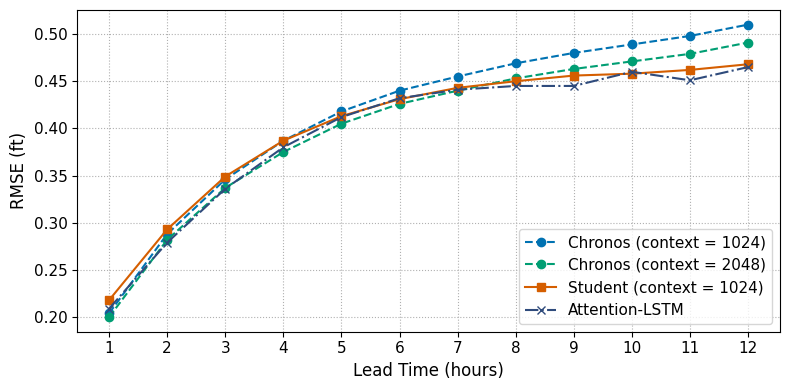

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 13), rmse_arr_1024, color='#0072B2', linestyle='--', marker='o', label='Chronos (context = 1024)')
plt.plot(range(1, 13), rmse_arr_2048, color='#009E73', linestyle='--', marker='o', label='Chronos (context = 2048)')
plt.plot(range(1, 13), rmse_arr_student, color='#D55E00', marker='s', label='Student (context = 1024)')
plt.plot(range(1, 13), rmse_arr_LSTM, color='#2F4B7C', linestyle='-.', marker='x', label='Attention-LSTM')

plt.xticks(range(1, 13))
plt.tick_params(axis='both', labelsize=11)
plt.xlabel('Lead Time (hours)', fontsize=12)
plt.ylabel('RMSE (ft)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle=':')
plt.tight_layout()
# plt.savefig('summary.png', dpi=1200)
plt.show()

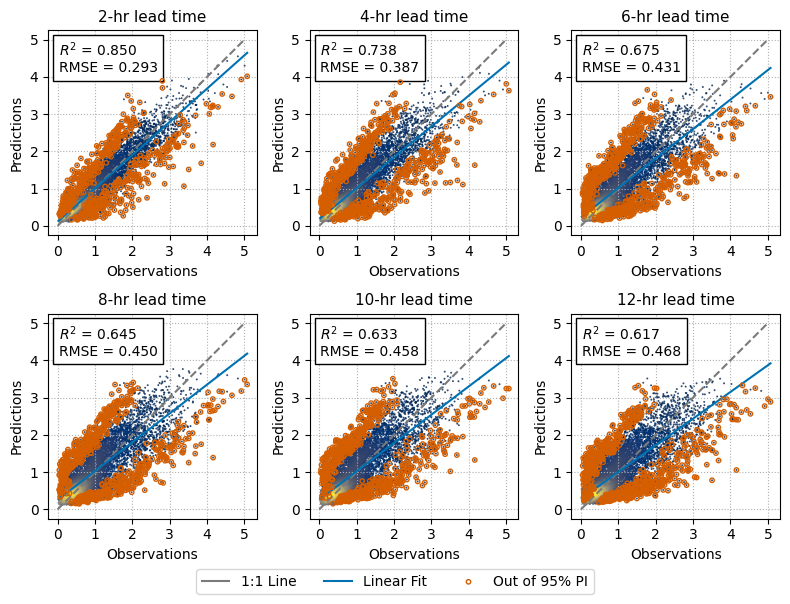

In [5]:
def pred_vs_obs(y_true, y_pred, rmse_arr, exceed):
    fig, axes = plt.subplots(2, 3, figsize=(8, 6))
    axes = axes.flatten()
    baseline, = plt.plot([], [], color='#7A7A7A', label='1:1 Line')
    fit_line, = plt.plot([], [], color='#0072B2', label='Linear Fit')

    for i in range(1, 12, 2):
        ax = axes[i // 2]
        yt, yp = y_true[:, i], y_pred[:, i].flatten()
        
        ax.plot([0, 5], [0, 5], color='#7A7A7A', linestyle='--')
        ax.plot(np.unique(yt), np.poly1d(np.polyfit(yt, yp, 1))(np.unique(yt)), color='#0072B2')
        kernel = stats.gaussian_kde(np.vstack([yt, yp]))(np.vstack([yt, yp]))
        ax.scatter(yt, yp, c=kernel, s=2, cmap='cividis', alpha=0.8, edgecolors='none')
        scatter = ax.scatter(yt[exceed[:,i]], yp[exceed[:,i]], facecolors='none', edgecolors='#D55E00', s=10, label='Out of 95% PI', zorder=10)

        ax.set_title(f'{i+1}-hr lead time', fontsize=11)
        ax.set_xticks([0, 1, 2, 3, 4, 5])
        ax.set(xlabel='Observations', ylabel='Predictions')
        ax.text(0.05, 0.95, f'$R^2$ = {r2_score(yt, yp):.3f}\nRMSE = {rmse_arr[i]:.3f}',
                transform=ax.transAxes, verticalalignment='top', bbox=dict(facecolor='white', edgecolor='black'))
        ax.grid(True, linestyle=':')

    fig.legend(handles=[baseline, fit_line, scatter], loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.01))
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    # plt.savefig('pred_vs_obs.png', dpi=1200, bbox_inches='tight')
    plt.show()

exceed = (y_true < y_pred_p95L) | (y_true > y_pred_p95U)
pred_vs_obs(y_true, y_pred_p50, rmse_arr, exceed)

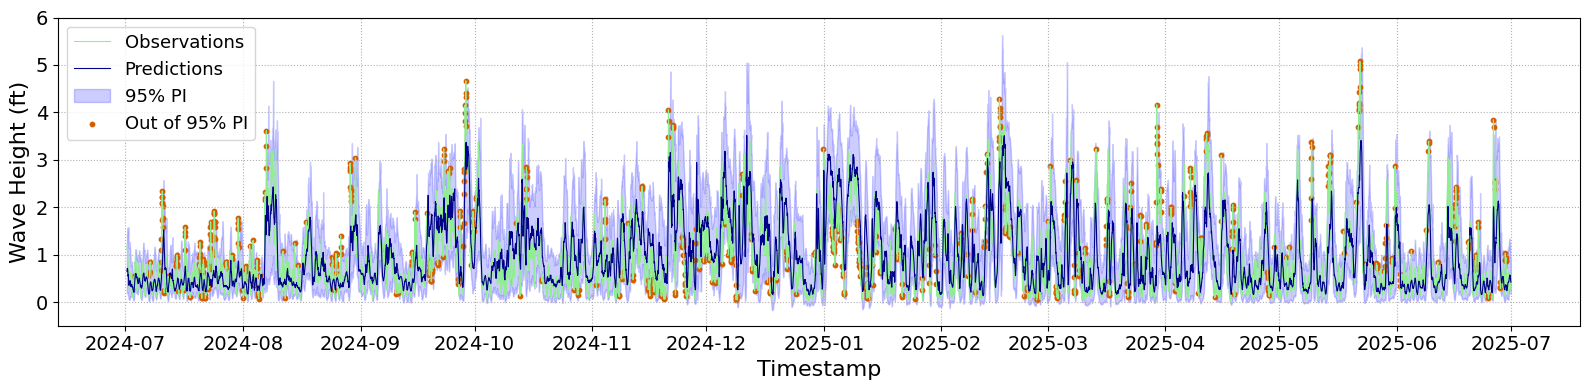

In [6]:
idx = 11
time_idx = df_test['TmStamp'].iloc[idx:idx+len(y_true)]
y_obs = y_true[:, idx]
y_lower = y_pred_p95L[:, idx]
y_upper = y_pred_p95U[:, idx]
mask = (y_obs < y_lower) | (y_obs > y_upper)

plt.figure(figsize=(16, 4))
plt.plot(time_idx, y_obs, linewidth=0.8, color='lightgreen', label='Observations')
plt.plot(time_idx, y_pred_p50[:, idx], linewidth=0.8, color='darkblue', label='Predictions')
plt.fill_between(time_idx, y_lower, y_upper, color='b', alpha=0.2, label='95% PI')
plt.scatter(time_idx[mask], y_obs[mask], color='#D55E00', s=10, label='Out of 95% PI')

plt.ylim(-0.5, 6)
plt.tick_params(axis='both', labelsize=14)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Timestamp', fontsize=16)
plt.ylabel('Wave Height (ft)', fontsize=16)
plt.legend(fontsize=13)

plt.grid(True, linestyle=':')
plt.tight_layout()
# plt.savefig('ts_comparison.png', dpi=1200)
plt.show()